In [73]:
import requests
import pandas as pd

In [5]:
url = "https://data.cityofnewyork.us/resource/8zf9-spf8.json?$limit=5"
response = requests.get(url)
data = response.json()
print(data)

[{'summons_number': '9058484970', 'plate_id': 'KPX6651', 'registration_state': 'NY', 'plate_type': 'PAS', 'issue_date': '2023-07-17T00:00:00.000', 'violation_code': '71', 'vehicle_body_type': '4DSD', 'vehicle_make': 'TOYOT', 'issuing_agency': 'T', 'street_code1': '14690', 'street_code2': '14840', 'street_code3': '8630', 'vehicle_expiration_date': '20250617', 'violation_location': '115', 'violation_precinct': '115', 'issuer_precinct': '115', 'issuer_code': '354002', 'issuer_command': 'T401', 'issuer_squad': 'G', 'violation_time': '0143P', 'violation_county': 'Q', 'violation_in_front_of_or': 'O', 'house_number': '35-35', 'street_name': '69th St', 'date_first_observed': '0', 'law_section': '408', 'sub_division': 'J6', 'days_parking_in_effect': 'YYYYYYY', 'vehicle_color': 'GY', 'vehicle_year': '2009', 'feet_from_curb': '0', 'violation_post_code': '23', 'violation_description': '71A-Insp Sticker Expired (NYS)'}, {'summons_number': '9002272637', 'plate_id': 'KYF6667', 'registration_state': '

In [7]:
# Converting data to DataFrame
df = pd.DataFrame(data)
df.head()

,summons_number,plate_id,registration_state,plate_type,issue_date,violation_code,vehicle_body_type,vehicle_make,issuing_agency,street_code1,...,vehicle_year,feet_from_curb,violation_post_code,violation_description,intersecting_street,from_hours_in_effect,to_hours_in_effect,unregistered_vehicle,meter_number,violation_legal_code
0,9058484970,KPX6651,NY,PAS,2023-07-17T00:00:00.000,71,4DSD,TOYOT,T,14690,...,2009,0,23,71A-Insp Sticker Expired (NYS),NaN,NaN,NaN,NaN,NaN,NaN
1,9002272637,KYF6667,NY,PAS,2023-07-15T00:00:00.000,71,SUBN,VOLKS,T,60535,...,2019,0,17,71A-Insp Sticker Expired (NYS),15ft W/of Kent Ave,NaN,NaN,NaN,NaN,NaN
2,9065683781,KYY3128,NY,PAS,2023-07-23T00:00:00.000,40,PICK,CHEVR,T,18530,...,2022,0,1,40-Fire Hydrant,NaN,NaN,NaN,NaN,NaN,NaN
3,1491974643,KMK9140,NY,PAS,2023-06-30T00:00:00.000,98,SUBN,CHEVR,P,23520,...,2021,0,NaN,NaN,NaN,ALL,ALL,0,-,NaN
4,4852339752,MYGLOK26,NY,SRF,2023-07-16T00:00:00.000,36,SUBN,BMW,V,0,...,2021,0,NaN,PHTO SCHOOL ZN SPEED VIOLATION,E AVE,NaN,NaN,NaN,NaN,T


In [9]:
# Retrive 200 rows
url = "https://data.cityofnewyork.us/resource/8zf9-spf8.json?$limit=200"
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
print(len(df))

200


In [13]:
# Test to get 400 rows
all_data = []

for offset in range(0, 400, 200):
    url = f"https://data.cityofnewyork.us/resource/8zf9-spf8.json?$limit=200&$offset={offset}"
    response = requests.get(url)
    data = response.json()
    all_data.extend(data)

print(len(all_data))

400


In [14]:
# Now, since the test worked, we retrive 10,000 rows
all_data = []

for offset in range(0, 10000, 200):
    url = f"https://data.cityofnewyork.us/resource/8zf9-spf8.json?$limit=200&$offset={offset}"
    response = requests.get(url)
    data = response.json()
    all_data.extend(data)

print(len(all_data))

10000


In [16]:
# Creating the DataFrame
df = pd.DataFrame(all_data)
df.head()

,summons_number,plate_id,registration_state,plate_type,issue_date,violation_code,vehicle_body_type,vehicle_make,issuing_agency,street_code1,...,feet_from_curb,violation_post_code,violation_description,intersecting_street,from_hours_in_effect,to_hours_in_effect,unregistered_vehicle,meter_number,violation_legal_code,time_first_observed
0,9058484970,KPX6651,NY,PAS,2023-07-17T00:00:00.000,71,4DSD,TOYOT,T,14690,...,0,23,71A-Insp Sticker Expired (NYS),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9002272637,KYF6667,NY,PAS,2023-07-15T00:00:00.000,71,SUBN,VOLKS,T,60535,...,0,17,71A-Insp Sticker Expired (NYS),15ft W/of Kent Ave,NaN,NaN,NaN,NaN,NaN,NaN
2,9065683781,KYY3128,NY,PAS,2023-07-23T00:00:00.000,40,PICK,CHEVR,T,18530,...,0,1,40-Fire Hydrant,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1491974643,KMK9140,NY,PAS,2023-06-30T00:00:00.000,98,SUBN,CHEVR,P,23520,...,0,NaN,NaN,NaN,ALL,ALL,0,-,NaN,NaN
4,4852339752,MYGLOK26,NY,SRF,2023-07-16T00:00:00.000,36,SUBN,BMW,V,0,...,0,NaN,PHTO SCHOOL ZN SPEED VIOLATION,E AVE,NaN,NaN,NaN,NaN,T,NaN


In [18]:
# Saving the data
df.to_csv("parking_violations_dataset.csv", index = False)

In [ ]:
# Statistical Analysis

In [20]:
# Loading dataset
parking_violations = pd.read_csv("parking_violations_dataset.csv")
parking_violations.head()

,summons_number,plate_id,registration_state,plate_type,issue_date,violation_code,vehicle_body_type,vehicle_make,issuing_agency,street_code1,...,feet_from_curb,violation_post_code,violation_description,intersecting_street,from_hours_in_effect,to_hours_in_effect,unregistered_vehicle,meter_number,violation_legal_code,time_first_observed
0,9058484970,KPX6651,NY,PAS,2023-07-17T00:00:00.000,71,4DSD,TOYOT,T,14690,...,0,23.0,71A-Insp Sticker Expired (NYS),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9002272637,KYF6667,NY,PAS,2023-07-15T00:00:00.000,71,SUBN,VOLKS,T,60535,...,0,17.0,71A-Insp Sticker Expired (NYS),15ft W/of Kent Ave,NaN,NaN,NaN,NaN,NaN,NaN
2,9065683781,KYY3128,NY,PAS,2023-07-23T00:00:00.000,40,PICK,CHEVR,T,18530,...,0,1.0,40-Fire Hydrant,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1491974643,KMK9140,NY,PAS,2023-06-30T00:00:00.000,98,SUBN,CHEVR,P,23520,...,0,NaN,NaN,NaN,ALL,ALL,0.0,-,NaN,NaN
4,4852339752,MYGLOK26,NY,SRF,2023-07-16T00:00:00.000,36,SUBN,BMW,V,0,...,0,NaN,PHTO SCHOOL ZN SPEED VIOLATION,E AVE,NaN,NaN,NaN,NaN,T,NaN


In [21]:
parking_violations.info()
parking_violations.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   summons_number            10000 non-null  int64  
 1   plate_id                  10000 non-null  object 
 2   registration_state        10000 non-null  object 
 3   plate_type                10000 non-null  object 
 4   issue_date                9999 non-null   object 
 5   violation_code            10000 non-null  int64  
 6   vehicle_body_type         9987 non-null   object 
 7   vehicle_make              9993 non-null   object 
 8   issuing_agency            10000 non-null  object 
 9   street_code1              10000 non-null  int64  
 10  street_code2              10000 non-null  int64  
 11  street_code3              10000 non-null  int64  
 12  vehicle_expiration_date   10000 non-null  int64  
 13  violation_location        4444 non-null   float64
 14  violati

,summons_number,violation_code,street_code1,street_code2,street_code3,vehicle_expiration_date,violation_location,violation_precinct,issuer_precinct,issuer_code,date_first_observed,law_section,vehicle_year,feet_from_curb,violation_post_code,unregistered_vehicle
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,4444.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,2454.000000,237.0
mean,6.325517e+09,33.793000,14661.501700,12899.670800,12603.378500,1.093894e+07,65.569757,29.139200,27.740700,177646.981700,4.248446e+04,829.911200,1867.988900,0.058300,25.530562,0.0
std,2.290636e+09,16.554194,22107.562547,21032.056702,20852.358835,1.711051e+07,36.284120,40.579052,47.396558,221047.944866,9.261592e+05,378.481178,526.188531,0.552206,30.230270,0.0
min,1.326050e+09,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,0.0
25%,4.851908e+09,21.000000,0.000000,0.000000,0.000000,0.000000e+00,33.000000,0.000000,0.000000,0.000000,0.000000e+00,408.000000,2011.000000,0.000000,7.000000,0.0
50%,4.853570e+09,36.000000,0.000000,0.000000,0.000000,0.000000e+00,68.000000,0.000000,0.000000,0.000000,0.000000e+00,1111.000000,2017.000000,0.000000,18.000000,0.0
75%,9.062842e+09,36.000000,24360.000000,18990.000000,18950.000000,2.024052e+07,103.000000,62.000000,52.000000,366441.000000,0.000000e+00,1180.000000,2021.000000,0.000000,40.000000,0.0
max,9.070499e+09,99.000000,95030.000000,97760.000000,98100.000000,8.888889e+07,123.000000,123.000000,982.000000,983285.000000,2.023072e+07,1180.000000,2069.000000,10.000000,1003.000000,0.0


In [22]:
parking_violations.columns

Index(['summons_number', 'plate_id', 'registration_state', 'plate_type',
       'issue_date', 'violation_code', 'vehicle_body_type', 'vehicle_make',
       'issuing_agency', 'street_code1', 'street_code2', 'street_code3',
       'vehicle_expiration_date', 'violation_location', 'violation_precinct',
       'issuer_precinct', 'issuer_code', 'issuer_command', 'issuer_squad',
       'violation_time', 'violation_county', 'violation_in_front_of_or',
       'house_number', 'street_name', 'date_first_observed', 'law_section',
       'sub_division', 'days_parking_in_effect', 'vehicle_color',
       'vehicle_year', 'feet_from_curb', 'violation_post_code',
       'violation_description', 'intersecting_street', 'from_hours_in_effect',
       'to_hours_in_effect', 'unregistered_vehicle', 'meter_number',
       'violation_legal_code', 'time_first_observed'],
      dtype='object')

In [30]:
# Dropping columns with more than 56% of missing data 
cols_to_drop = [
    "unregistered_vehicle",
    "meter_number",
    "time_first_observed",
    "violation_post_code",
    "to_hours_in_effect",
    "from_hours_in_effect",
    "issuer_squad",
    "house_number",
    "days_parking_in_effect",
    "violation_in_front_of_or"
]

[col for col in cols_to_drop if col in parking_violations.columns]

parking_violations = parking_violations.drop(
    columns=cols_to_drop,
    errors="ignore"
)

In [31]:
# Checking now the percentage of missing value per column
parking_violations.isnull().mean().sort_values(ascending = False)

violation_location         0.5556
issuer_command             0.5549
violation_legal_code       0.4451
intersecting_street        0.3875
vehicle_color              0.0578
violation_description      0.0237
violation_county           0.0071
vehicle_body_type          0.0013
vehicle_make               0.0007
issue_date                 0.0001
sub_division               0.0001
street_name                0.0001
vehicle_year               0.0000
date_first_observed        0.0000
law_section                0.0000
feet_from_curb             0.0000
violation_time             0.0000
summons_number             0.0000
issuer_code                0.0000
plate_id                   0.0000
violation_precinct         0.0000
vehicle_expiration_date    0.0000
street_code3               0.0000
street_code2               0.0000
street_code1               0.0000
issuing_agency             0.0000
violation_code             0.0000
plate_type                 0.0000
registration_state         0.0000
issuer_precinc

In [33]:
# Checking how many rows we have left
parking_violations.shape

(10000, 30)

In [34]:
# Summary Statistics
parking_violations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   summons_number           10000 non-null  int64  
 1   plate_id                 10000 non-null  object 
 2   registration_state       10000 non-null  object 
 3   plate_type               10000 non-null  object 
 4   issue_date               9999 non-null   object 
 5   violation_code           10000 non-null  int64  
 6   vehicle_body_type        9987 non-null   object 
 7   vehicle_make             9993 non-null   object 
 8   issuing_agency           10000 non-null  object 
 9   street_code1             10000 non-null  int64  
 10  street_code2             10000 non-null  int64  
 11  street_code3             10000 non-null  int64  
 12  vehicle_expiration_date  10000 non-null  int64  
 13  violation_location       4444 non-null   float64
 14  violation_precinct     

In [35]:
parking_violations.describe()

,summons_number,violation_code,street_code1,street_code2,street_code3,vehicle_expiration_date,violation_location,violation_precinct,issuer_precinct,issuer_code,date_first_observed,law_section,vehicle_year,feet_from_curb
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,4444.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,6.325517e+09,33.793000,14661.501700,12899.670800,12603.378500,1.093894e+07,65.569757,29.139200,27.740700,177646.981700,4.248446e+04,829.911200,1867.988900,0.058300
std,2.290636e+09,16.554194,22107.562547,21032.056702,20852.358835,1.711051e+07,36.284120,40.579052,47.396558,221047.944866,9.261592e+05,378.481178,526.188531,0.552206
min,1.326050e+09,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,4.851908e+09,21.000000,0.000000,0.000000,0.000000,0.000000e+00,33.000000,0.000000,0.000000,0.000000,0.000000e+00,408.000000,2011.000000,0.000000
50%,4.853570e+09,36.000000,0.000000,0.000000,0.000000,0.000000e+00,68.000000,0.000000,0.000000,0.000000,0.000000e+00,1111.000000,2017.000000,0.000000
75%,9.062842e+09,36.000000,24360.000000,18990.000000,18950.000000,2.024052e+07,103.000000,62.000000,52.000000,366441.000000,0.000000e+00,1180.000000,2021.000000,0.000000
max,9.070499e+09,99.000000,95030.000000,97760.000000,98100.000000,8.888889e+07,123.000000,123.000000,982.000000,983285.000000,2.023072e+07,1180.000000,2069.000000,10.000000


In [ ]:
# The descriptive statistics reveal that many numerical fields in the dataset represent encoded categorical variables rather than true continuous measurements. 
# As a result, measures such as mean and standard deviation are not always directly interpretable. 
# Additionally, several fields such as vehicle year and date-related variables contain invalid or extreme values, suggesting data quality issues or inconsistent encoding. 
# Overall, the dataset requires careful preprocessing and categorical interpretation rather than purely statistical numerical analysis.

In [36]:
# Looking for the most common violations - just violation_code
parking_violations["violation_code"].value_counts().head(10)

# Pairing violation_code with its description
parking_violations.groupby(
    ["violation_code", "violation_description"]
).size().sort_values(ascending = False).head(10)

# The output has show three column: violation_code, violation_description, and count in descending order

violation_code  violation_description         
36              PHTO SCHOOL ZN SPEED VIOLATION    4617
21              21-No Parking (street clean)       806
7               FAILURE TO STOP AT RED LIGHT       566
38              38-Failure to Dsplay Meter Rec     552
71              71A-Insp Sticker Expired (NYS)     339
14              14-No Standing                     329
40              40-Fire Hydrant                    308
5               BUS LANE VIOLATION                 288
21              No Parking Street Cleaning         281
20              20A-No Parking (Non-COM)           261
dtype: int64

In [74]:
# Renamed description for clearity and combine code 21, since it is repeated
parking_violations["violations_description"] = (
    parking_violations["violation_description"]
    .replace({
        "PHTO SCHOOL ZN SPEED VIOLATION": "School Zone Speeding",
        "21-No Parking (street clean)": "No Parking - Street Cleaning",
        "No Parking Street Cleaning": "No Parking - Street Cleaning",
        "FAILURE TO STOP AT RED LIGHT": "Red Light Violation",
        "38-Failure to Dsplay Meter Rec": "Failure to Display Meter Receipt",
        "71A-Insp Sticker Expired (NYS)": "Expired Inspection Sticker",
        "14-No Standing": "No Standing",
        "40-Fire Hydrant": "Fire Hydrant Violation",
        "BUS LANE VIOLATION": "Bus Lane Violation",
        "20A-No Parking (Non-COM)": "No Parking - Non Commercial"
    })
)

In [76]:
parking_violations.groupby(
    ["violation_code", "violations_description"]
).size().sort_values(ascending=False).head(10)

violation_code  violations_description          
36              School Zone Speeding                4617
21              No Parking - Street Cleaning        1087
7               Red Light Violation                  566
38              Failure to Display Meter Receipt     552
71              Expired Inspection Sticker           339
14              No Standing                          331
40              Fire Hydrant Violation               308
5               Bus Lane Violation                   288
20              No Parking - Non Commercial          261
70              70A-Reg. Sticker Expired (NYS)       259
dtype: int64

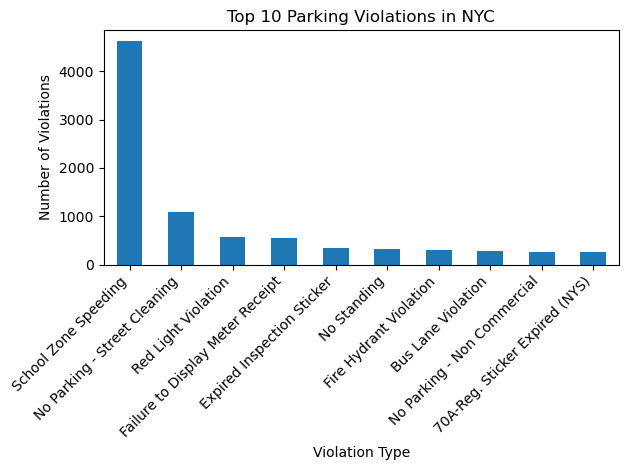

In [78]:
# Using a bar chart for better reading
import matplotlib.pyplot as plt

# Create top violations table
top_violations = (
    parking_violations
    .groupby("violations_description")
    .size()
    .sort_values(ascending = False)
    .head(10)
)

# Create bar chart
top_violations.plot(kind = "bar")

# Labels and title
plt.title("Top 10 Parking Violations in NYC")
plt.xlabel("Violation Type")
plt.ylabel("Number of Violations")

# Rotate labels for readability
plt.xticks(rotation=45, ha="right")

# Improve layout
plt.tight_layout()

# Show chart
plt.show()

In [79]:
# Taking now a look to top vhicle with violation
top_vehicle_makes = (
    parking_violations["vehicle_make"]
    .value_counts()
    .head(10)
)

top_vehicle_makes

vehicle_make
HONDA    1500
TOYOT    1100
NISSA     986
FORD      656
BMW       557
JEEP      556
ME/BE     555
CHEVR     440
HYUND     378
LEXUS     310
Name: count, dtype: int64

In [80]:
# Making more clear the brand of the vehicle in order to avoid mistakes or misunderstanding 
vehicle_map = {
    "TOYOT": "TOYOTA",
    "NISSA": "NISSAN",
    "CHEVR": "CHEVROLET",
    "HYUND": "HYUNDAI",
    "ME/BE": "MERCEDES-BENZ"
}

parking_violations["vehicle_make_clean"] = (
    parking_violations["vehicle_make"]
    .replace(vehicle_map)
)

parking_violations["vehicle_make_clean"].value_counts().head(10)

vehicle_make_clean
HONDA            1500
TOYOTA           1100
NISSAN            986
FORD              656
BMW               557
JEEP              556
MERCEDES-BENZ     555
CHEVROLET         440
HYUNDAI           378
LEXUS             310
Name: count, dtype: int64

In [ ]:
# The most frequently appearing vehicle makes include Honda, Toyota, and Nissan, which are also among the most common vehicle brands in urban populations. 
# This suggests that parking violations largely reflect general vehicle distribution in NYC rather than brand-specific targeting. 

In [81]:
# Interesting is a first preliminary analysis on counties and/or borough
top_counties = (
    parking_violations["violation_county"]
    .value_counts()
)

top_counties

violation_county
QN       2352
BK       1609
K        1264
BX       1235
NY       1176
Q        1140
ST        413
MN        381
Kings     141
R         100
Bronx      82
Qns        36
Name: count, dtype: int64

In [49]:
# Replacing counties with thier assigned borough
borough_map = {
    "QN": "Queens",
    "Q": "Queens",
    "Qns": "Queens",
    "BK": "Brooklyn",
    "K": "Brooklyn",
    "Kings": "Brooklyn",
    "BX": "Bronx",
    "Bronx": "Bronx",
    "MN": "Manhattan",
    "NY": "Manhattan",
    "R": "Staten Island",
    "ST": "Staten Island"
}

parking_violations["violation_borough"] = (
    parking_violations["violation_county"]
    .replace(borough_map)
)

parking_violations["violation_borough"].value_counts()

violation_borough
Queens           3528
Brooklyn         3014
Manhattan        1557
Bronx            1317
Staten Island     513
Name: count, dtype: int64

In [ ]:
# Parking violations are concentrated in Queens and Brooklyn, with Queens (QN) showing the highest number of violations. 
# However, the dataset contains inconsistent naming conventions for counties (e.g., BK vs Kings, QN vs Qns), which required interpretation and consolidation. 
# We discovered a data quality problem again: duplicate labels for same borough, and inconsistent abbreviations. 

In [64]:
# Geographical Analysis

In [65]:
# Geographical Analysis

In [66]:
# Violations per borough
borough_counts = parking_violations["violation_borough"].value_counts()
borough_counts

violation_borough
Queens           3528
Brooklyn         3014
Manhattan        1557
Bronx            1317
Staten Island     513
Name: count, dtype: int64

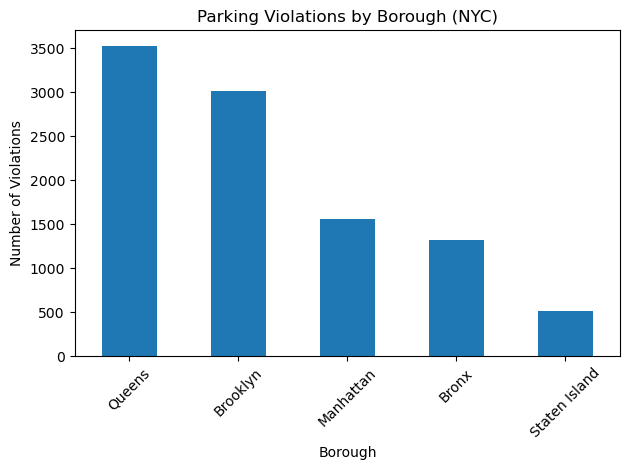

In [67]:
# Visualization of violations per borough
import matplotlib.pyplot as plot

borough_counts.plot(kind = "bar")

plt.title("Parking Violations by Borough (NYC)")
plt.xlabel("Borough")
plt.ylabel("Number of Violations")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
# Based on our previous analysis, we grouped all the locations (counties, city, etc) into borough and we summarized in a clear and readable graph: 

In [46]:
# Team members
# Federico Ciandri
# Sabrina Zhu
# Yongheng Guan

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [53]:
# Analysis by precinct - police station identified by code
top_precincts_borough = (
    parking_violations[parking_violations["violation_precinct"] != 0]
    .groupby(["violation_precinct", "violation_borough"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top_precincts_borough.head(10)

,violation_precinct,violation_borough,count
71,114,Queens,181
66,109,Queens,130
10,19,Manhattan,119
72,115,Queens,116
53,84,Brooklyn,114
42,70,Brooklyn,114
35,61,Brooklyn,107
2,6,Manhattan,99
60,103,Queens,93
69,112,Queens,89


In [72]:
# Parking violations are heavily concentrated in a small number of precincts, particularly in Queens and Brooklyn. 
# Queens precincts dominate the highest-ranking positions, indicating localized enforcement of intensity or higher parking demand. 
# Brooklyn shows a more distributed pattern across multiple precincts, while Manhattan has fewer but still notable hotspots. 
# The distribution suggests that parking violations are not uniform across NYC, but instead clustered in specific precincts, which may be linked to residential density, commercial activity, or enforcement policy differences. 

In [54]:
# Street hotspot:
top_streets = (
    parking_violations["street_name"]
    .value_counts()
    .head(10)
)

top_streets

street_name
WB N CONDUIT AVE @ 8    531
WB N CONDUIT AVE @ S     80
Broadway                 55
SB WOODHAVEN BLVD @      51
WB HORACE HARDING EX     48
NB CROSS BAY BLVD @      47
WB ASTORIA BLVD N @      45
EB HORACE HARDING EX     43
NB FRANCIS LEWIS BLV     35
SB FRANCIS LEWIS BLV     34
Name: count, dtype: int64

In [55]:
# Isolating the higest street ranked in our table based on violations:
conduit_data = parking_violations[
    parking_violations["street_name"] == "WB N CONDUIT AVE @ 8"
]

conduit_data.head()

,summons_number,plate_id,registration_state,plate_type,issue_date,violation_code,vehicle_body_type,vehicle_make,issuing_agency,street_code1,...,sub_division,vehicle_color,vehicle_year,feet_from_curb,violation_description,intersecting_street,violation_legal_code,violations_description,vehicle_make_clean,violation_borough
5,4852333877,LAK7088,NY,PAS,2023-07-16T00:00:00.000,36,4DSD,TOYOT,V,0,...,B,GY,2016,0,PHTO SCHOOL ZN SPEED VIOLATION,8TH ST,T,School Zone Speeding,TOYOTA,Queens
9,4852872272,KJL7113,NY,PAS,2023-07-19T00:00:00.000,36,SUBN,NISSA,V,0,...,B,GR,2023,0,PHTO SCHOOL ZN SPEED VIOLATION,8TH ST,T,School Zone Speeding,NISSAN,Queens
17,4852781655,LAR2684,NY,PAS,2023-07-17T00:00:00.000,36,SUBN,TOYOT,V,0,...,B,WH,2023,0,PHTO SCHOOL ZN SPEED VIOLATION,8TH ST,T,School Zone Speeding,TOYOTA,Queens
19,4852418100,KNU7588,NY,PAS,2023-07-17T00:00:00.000,36,SUBN,NISSA,V,0,...,B,BK,2021,0,PHTO SCHOOL ZN SPEED VIOLATION,8TH ST,T,School Zone Speeding,NISSAN,Queens
38,4852671310,GKZ5202,NY,PAS,2023-07-19T00:00:00.000,36,4DSD,HYUND,V,0,...,B,WH,2013,0,PHTO SCHOOL ZN SPEED VIOLATION,8TH ST,T,School Zone Speeding,HYUNDAI,Queens


In [56]:
# Identifying what is the most common violations on that street
conduit_data["violation_description"].value_counts()

violation_description
PHTO SCHOOL ZN SPEED VIOLATION    531
Name: count, dtype: int64

In [ ]:
# After a careful review, we noticed that the highest infraction in this street it is actually a school zone speeding violation.
# This indicates that the hotspot is not a traditional parking enforcement area, but rather an automated speed camera location generating repeated violations. 
# This also suggests that enforcement patterns are driven by traffic safety infrastructure (school zones and cameras) rather than random parking infractions.

In [57]:
# Temporal Analysis 

In [59]:
# Converting the issue_date column into a datetime format, and
# Extracting the month and counting the number of parking violations occurring in each month
parking_violations["issue_date"] = pd.to_datetime(parking_violations["issue_date"], errors="coerce")
parking_violations["month"] = parking_violations["issue_date"].dt.month
monthly_counts = parking_violations["month"].value_counts().sort_index()
monthly_counts

month
1.0       1
2.0       1
4.0       1
5.0      12
6.0    1644
7.0    8340
Name: count, dtype: int64

In [60]:
# Immediately noticing some discrepancies in our analysis, as June and July have a pick, but for other months the results are null

In [62]:
# Deciding to take a closer look at the actual recorded time of the dataset
parking_violations["issue_date"].min(), parking_violations["issue_date"].max()

(Timestamp('2023-01-09 00:00:00'), Timestamp('2025-06-16 00:00:00'))

In [68]:
# Based on our code, the dataset spans multiple years (2023–2025), but the distribution of records across time is highly uneven, with most observations concentrated in mid-2023 to mid-2025. As a result, monthly trends should not be interpreted as true seasonal patterns, but rather as a reflection of uneven data availability across the extracted sample.